# Modelagem com auto ML e LLM para predição de sucesso em campanha de telemarketing

_Objetivo: Classificar se um cliente irá (ou não) realizar um depósito, levando em conta informações de campanhas de marketing via telefone._

**Dataset:** [Bank Marketing (UCI)](https://archive.ics.uci.edu/dataset/222/bank+marketing)

## Setups iniciais

In [1]:
REDUCE_DATASETS = False
PERC_DATASET = 0.01

TEST_SIZE = 0.2
MODEL_TIME_BUDGET = 180
MODEL_METRIC = 'f1'  # busca não perder possíveis clientes que fazem depósito e não ligar demais gerando custos desnecessários (minimizar FN e FP)

PATH_DATASET_BANK_FULL = 'datasets/bank-full.csv'
PATH_INFOS_BANK_FULL = 'datasets/bank-names.txt'

REPORT_FILE_PATH = 'reports/report_eda_v1.html'
TRAINED_MODEL_PATH = 'trained_models/opt_model_pipeline__full_dataset_v1.pkl'

https://microsoft.github.io/FLAML/docs/Use-Cases/Task-Oriented-AutoML/#optimization-metric

### Carrega bibliotecas

In [2]:
import pickle
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import IFrame
from rich import print

from ydata_profiling import ProfileReport
import phik

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from flaml import AutoML

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq

load_dotenv()
%matplotlib inline
pd.set_option('display.max_columns', None)
np.random.seed(42)

## Prepara dataset

In [3]:
df_bank_full = pd.read_csv(PATH_DATASET_BANK_FULL, sep=';')

if REDUCE_DATASETS:
    df_bank_full = df_bank_full.sample(n=round(PERC_DATASET*df_bank_full.shape[0]), random_state=42)

print('Full dataset:')
print(df_bank_full.shape)
display(df_bank_full.head())

Full dataset:

(45211, 17)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Divide dataset em treino e teste

### Define features

In [4]:
cols_to_remove = ['y']

In [5]:
cols_features = [col for col in df_bank_full.columns if col not in cols_to_remove]
print(cols_features)

[
    'age',
    'job',
    'marital',
    'education',
    'default',
    'balance',
    'housing',
    'loan',
    'contact',
    'day',
    'month',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'poutcome'
]

In [ ]:
df_train, df_test = train_test_split(df_bank_full, test_size=TEST_SIZE, random_state=42)

x_test = df_test.drop(columns='y')
y_test = df_test['y']

In [7]:
df_train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000
mean,40.930823,1361.046146,15.817739,256.891202,2.765649,40.180076,0.580264
std,10.618369,3023.083187,8.325860,256.884103,3.120193,100.107617,2.370668
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,70.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,447.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1429.000000,21.000000,318.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
df_train = df_train[
    (df_train['duration'] <= df_train['duration'].quantile(0.99)) &
    (df_train['campaign'] <= df_train['campaign'].quantile(0.99))
]

In [9]:
x_train = df_train.drop(columns=cols_to_remove)
y_train = df_train['y']

### EDA com YData Profiling

In [10]:
profile = ProfileReport(df_train, title='Report dataset Bank Marketing', explorative=True)

profile.to_file(REPORT_FILE_PATH)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 853.25it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
IFrame(src=REPORT_FILE_PATH, width=1200, height=800)

**Resultados esperados:**

<img src="imgs/overview_report.png">

<img src="imgs/alerts_report.png">

<img src="imgs/corr_report.png">

In [12]:
x_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
3344,41,blue-collar,married,primary,no,849,yes,no,unknown,15,may,72,1,-1,0,unknown
17965,49,technician,married,primary,no,1415,yes,no,cellular,30,jul,269,2,-1,0,unknown
18299,42,admin.,married,secondary,no,3842,no,no,cellular,31,jul,130,4,-1,0,unknown
10221,37,management,single,tertiary,no,-119,yes,no,unknown,11,jun,375,11,-1,0,unknown
32192,56,blue-collar,married,primary,no,3498,no,no,cellular,15,apr,264,2,-1,0,unknown


### Explora distribuições e correlações

In [13]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35494 entries, 3344 to 15795
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        35494 non-null  int64 
 1   job        35494 non-null  object
 2   marital    35494 non-null  object
 3   education  35494 non-null  object
 4   default    35494 non-null  object
 5   balance    35494 non-null  int64 
 6   housing    35494 non-null  object
 7   loan       35494 non-null  object
 8   contact    35494 non-null  object
 9   day        35494 non-null  int64 
 10  month      35494 non-null  object
 11  duration   35494 non-null  int64 
 12  campaign   35494 non-null  int64 
 13  pdays      35494 non-null  int64 
 14  previous   35494 non-null  int64 
 15  poutcome   35494 non-null  object
dtypes: int64(7), object(9)
memory usage: 5.6+ MB


In [14]:
y_train.value_counts(dropna=False)

y
no     31521
yes     3973
Name: count, dtype: int64

In [15]:
df_train_yes = df_train[df_train.y=='yes']
df_train_no = df_train[df_train.y=='no']

In [16]:
def compare_values_cat(col: str) -> None:
    df_counts = pd.concat(
        [
            df_train[col].value_counts(),
            df_train_yes[col].value_counts(),
            df_train_no[col].value_counts()
        ],
        axis=1
    )
    df_counts.columns = ['total', 'yes', 'no']
    
    df_counts = df_counts.fillna(0).astype(int)
    
    df_counts['%yes'] = (df_counts['yes'] / df_counts['total'] * 100).round(2)
    df_counts['%no']  = (df_counts['no']  / df_counts['total'] * 100).round(2)
    
    df_counts = df_counts.sort_values('%yes', ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    df_counts[['total', 'yes', 'no']].plot(kind='barh', ax=axes[0])
    axes[0].set_title(f'{col} distribution')
    
    axes[1].axis('off')
    table = axes[1].table(
        cellText=df_counts.values,
        colLabels=df_counts.columns,
        rowLabels=df_counts.index,
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)
    
    plt.tight_layout()
    plt.show()

In [17]:
cols_to_check = ['poutcome', 'month', 'contact', 'job', 'housing']

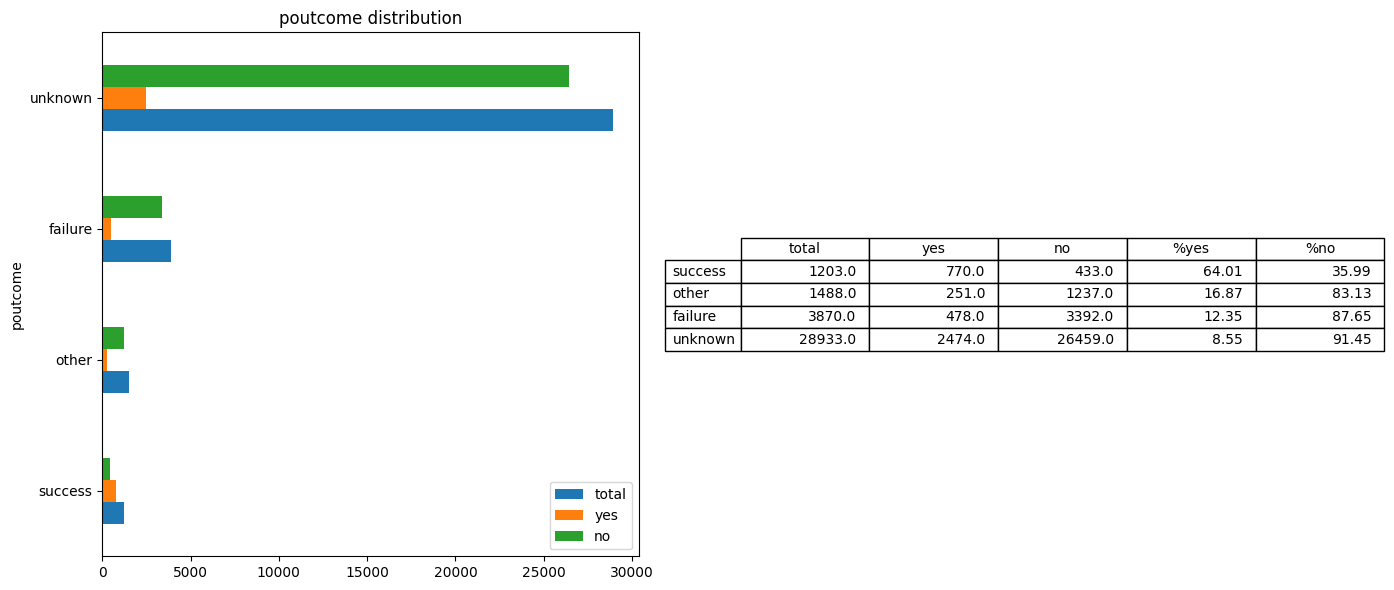

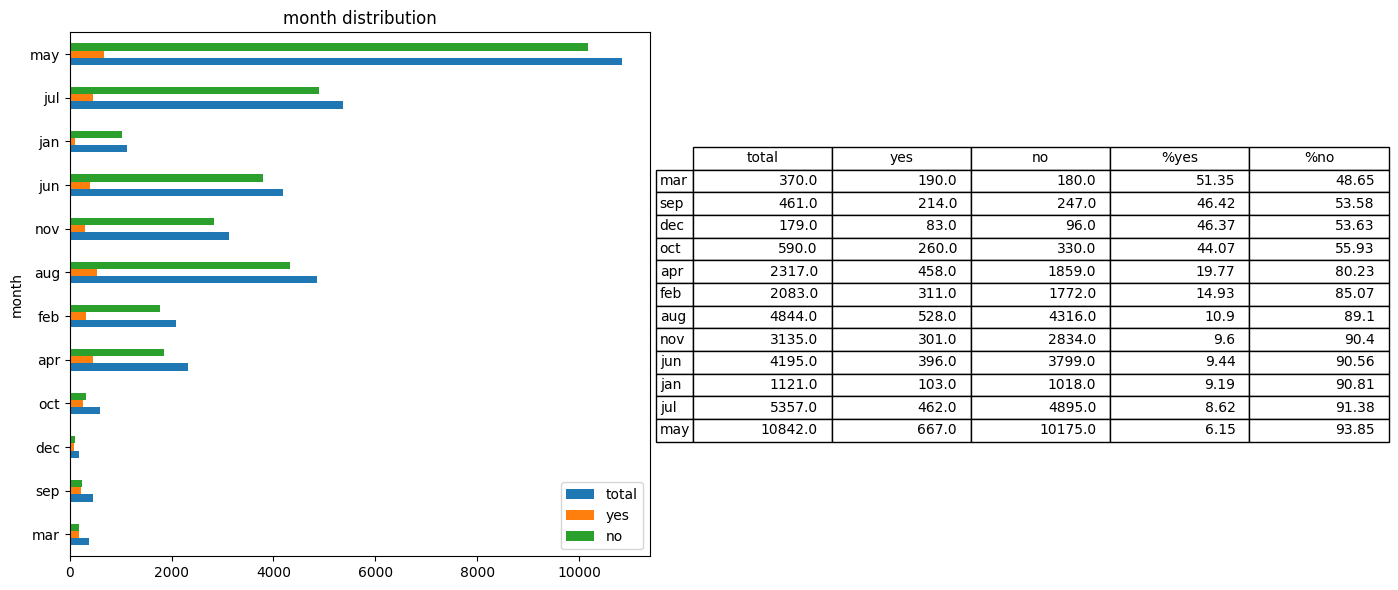

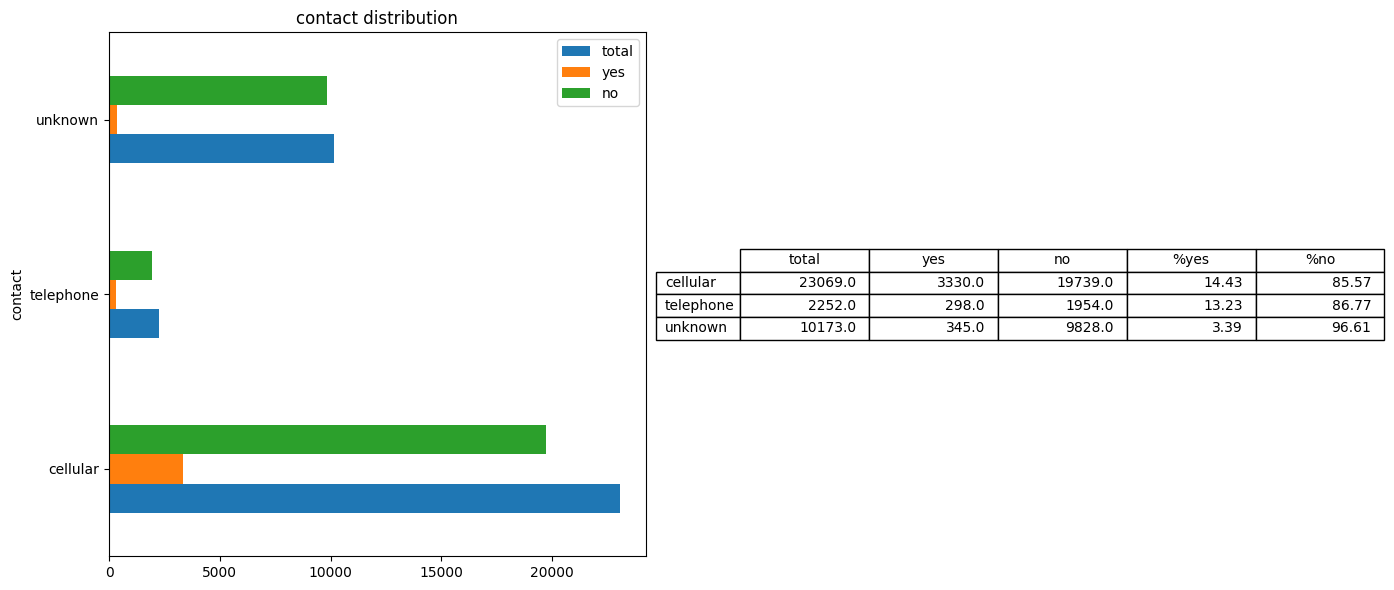

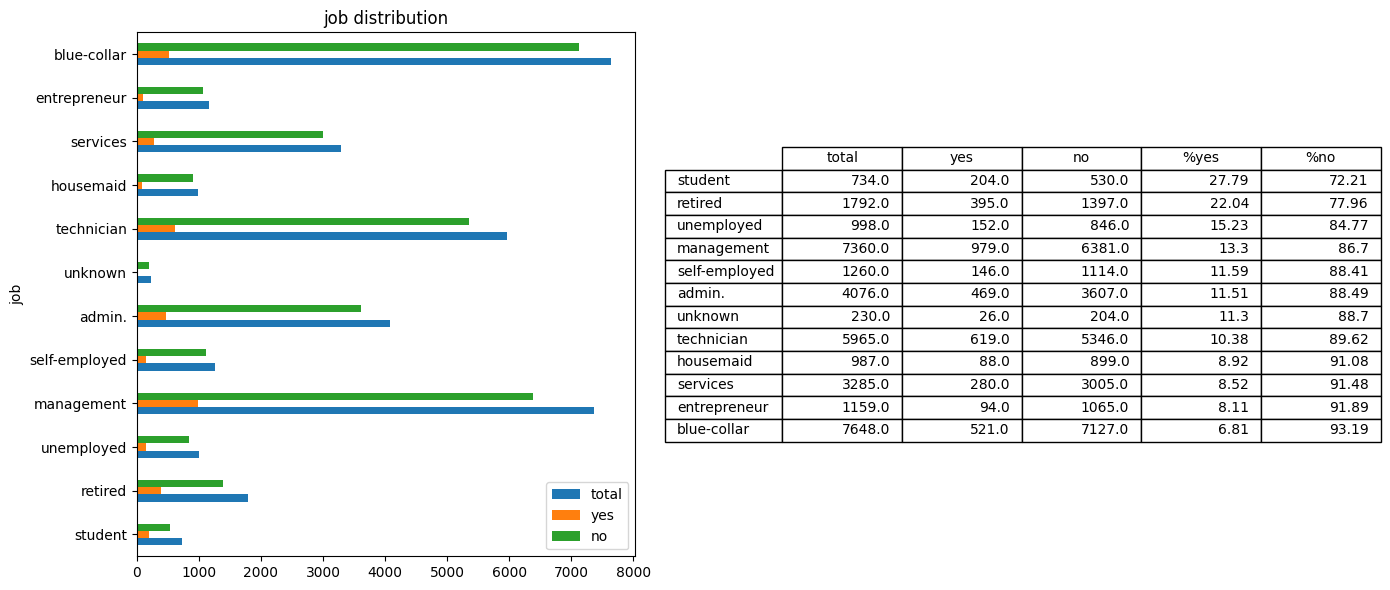

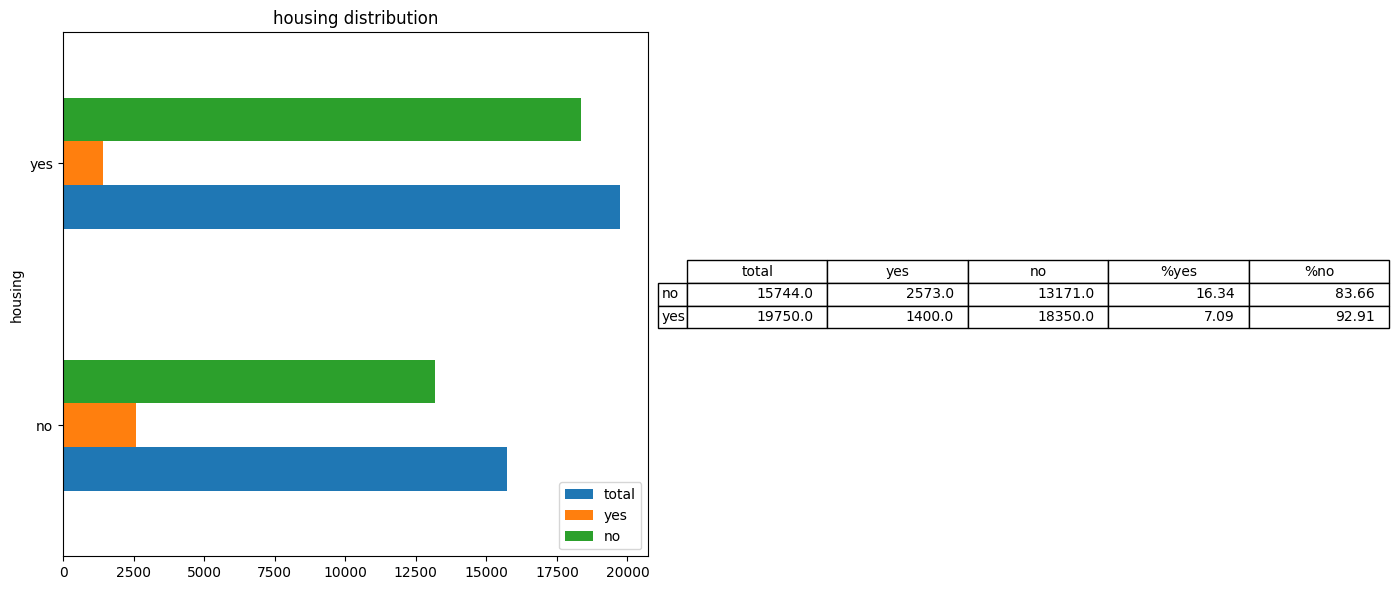

In [18]:
for col in cols_to_check:
    compare_values_cat(col=col)

In [19]:
df_train_corr = df_train.phik_matrix()
df_train_corr

interval columns not set, guessing: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
age,1.000000,0.505101,0.481245,0.225595,0.024935,0.193327,0.294173,0.082451,0.258401,0.103365,0.225871,0.088941,0.067868,0.109648,0.000000,0.108249,0.215061
job,0.505101,1.000000,0.416187,0.768930,0.043417,0.080651,0.363032,0.130992,0.309759,0.100293,0.357391,0.046888,0.049712,0.100875,0.000000,0.130510,0.173923
marital,0.481245,0.416187,1.000000,0.129719,0.007299,0.033127,0.010360,0.030153,0.141358,0.046280,0.162068,0.028432,0.054692,0.043057,0.000000,0.031794,0.038590
education,0.225595,0.768930,0.129719,1.000000,0.016304,0.078018,0.184406,0.119016,0.130807,0.068756,0.229482,0.016093,0.024644,0.077772,0.000000,0.087614,0.110218
default,0.024935,0.043417,0.007299,0.016304,1.000000,0.062227,0.000000,0.117518,0.011701,0.017338,0.078650,0.002614,0.020748,0.047124,0.000000,0.061629,0.033936
balance,0.193327,0.080651,0.033127,0.078018,0.062227,1.000000,0.078830,0.100536,0.056566,0.096136,0.135907,0.022708,0.000000,0.078681,0.000000,0.038499,0.073899
housing,0.294173,0.363032,0.010360,0.184406,0.000000,0.078830,1.000000,0.069020,0.125575,0.163638,0.640646,0.024813,0.043378,0.216717,0.001469,0.210543,0.226773
loan,0.082451,0.130992,0.030153,0.119016,0.117518,0.100536,0.069020,1.000000,0.008525,0.058675,0.234998,0.020124,0.000000,0.035448,0.000000,0.078939,0.107212
contact,0.258401,0.309759,0.141358,0.130807,0.011701,0.056566,0.125575,0.008525,1.000000,0.140710,0.788519,0.068267,0.091845,0.317746,0.025328,0.219204,0.094753
day,0.103365,0.100293,0.046280,0.068756,0.017338,0.096136,0.163638,0.058675,0.140710,1.000000,0.597986,0.077355,0.170029,0.236304,0.008783,0.135337,0.098102


In [20]:
df_train_corr['y'].sort_values(ascending=False)

y            1.000000
duration     0.504633
poutcome     0.473095
month        0.346459
pdays        0.264143
housing      0.226773
age          0.215061
job          0.173923
education    0.110218
loan         0.107212
day          0.098102
contact      0.094753
campaign     0.092893
balance      0.073899
marital      0.038590
default      0.033936
previous     0.000000
Name: y, dtype: float64

## Treinamento

### Encode das colunas não numéricas

In [21]:
cat_cols = x_train.select_dtypes(include='object').columns
num_cols = x_train.select_dtypes(include='number').columns

In [22]:
onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

### Treina modelo

In [23]:
automl = AutoML()

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', onehot_encoder, cat_cols),
        ('num', 'passthrough', num_cols),
    ]
)
pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', automl)
    ]
)

#### Treina modelo com FLAML AutoML

In [25]:
pipeline.fit(
    X=x_train[cols_features],
    y=y_train,
    model__task='classification',
    model__metric=MODEL_METRIC,
    model__time_budget=MODEL_TIME_BUDGET,
    model__verbose=0,    
)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Resultados esperado:**

<img src="./imgs/pipeline_sklearn.png">

### Modelo ótimo

In [26]:
# modelos candidatos
pd.DataFrame(pipeline.named_steps['model'].best_config_per_estimator)

,lgbm,rf,xgboost,extra_tree,xgb_limitdepth,sgd,catboost,lrl1
n_estimators,82.000000,7,83.000000,4,41.000000,NaN,8192.000000,NaN
num_leaves,59.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min_child_samples,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
learning_rate,0.150047,NaN,0.078639,NaN,0.858888,constant,0.062336,NaN
log_max_bin,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
colsample_bytree,0.578852,NaN,0.733032,NaN,0.829895,NaN,NaN,NaN
reg_alpha,0.000977,NaN,0.021022,NaN,0.002109,NaN,NaN,NaN
reg_lambda,0.111117,NaN,1.318054,NaN,0.000977,NaN,NaN,NaN
max_features,NaN,0.587076,NaN,0.482135,NaN,NaN,NaN,NaN
max_leaves,NaN,393,116.000000,130,NaN,NaN,NaN,NaN


In [27]:
print('\n=== Modelo ótimo ===\n')
print(f'Name: {pipeline.named_steps['model'].best_estimator}')
print(f'Loss: {pipeline.named_steps['model'].best_loss}')

=== Modelo ótimo ===

Name: lgbm

Loss: 0.43181818181818177

### Exporta modelo treinado

In [28]:
with open(TRAINED_MODEL_PATH, 'wb') as f:
    pickle.dump(pipeline, f)

## Predições com modelo treinado

In [29]:
def compute_metrics(x: pd.DataFrame, y: pd.Series, suffix: str = None) -> pd.DataFrame:
    y_pred = pipeline.predict(x[cols_features])
    y_prob = pipeline.predict_proba(x[cols_features])[:,1]
    
    y_num = [1 if i == 'yes' else 0 for i in y]
    y_pred_num = [1 if i == 'yes' else 0 for i in y_pred]

    metrics = {
        f'f1_{suffix}': f1_score(y_num, y_pred_num),
        f'accuracy_{suffix}': accuracy_score(y_num, y_pred_num),
        f'precision_{suffix}': precision_score(y_num, y_pred_num),
        f'recall_{suffix}': recall_score(y_num, y_pred_num),
        f'roc_auc_{suffix}': roc_auc_score(y_num, y_prob),
    }

    return pd.DataFrame(metrics, index=['metrics'])

In [30]:
train_metrics = compute_metrics(x=x_train, y=y_train, suffix='train')
test_metrics = compute_metrics(x=x_test, y=y_test, suffix='test')

In [31]:
print(f'x_train.shape: {x_train.shape}')
print(f'x_test.shape: {x_test.shape}')

x_train.shape: (35494, 16)

x_test.shape: (9043, 16)

### Tabela com métricas

In [32]:
all_metrics = pd.concat([train_metrics, test_metrics], axis=1).T
all_metrics

,metrics
f1_train,0.766226
accuracy_train,0.953119
precision_train,0.867091
recall_train,0.686383
roc_auc_train,0.981754
f1_test,0.566929
accuracy_test,0.908769
precision_test,0.663391
recall_test,0.494959
roc_auc_test,0.935015


### Gráfico comparativo

In [33]:
def plot_train_test_metrics(metrics_train: pd.DataFrame, metrics_test: pd.DataFrame):
    metrics = [col.replace('_train','').replace('_test','') for col in metrics_train.columns]

    train_values = metrics_train.iloc[0].values
    test_values  = metrics_test.iloc[0].values

    x = np.arange(len(metrics))
    width = 0.3

    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, train_values, width, label='Train', color='darkblue')
    rects2 = ax.bar(x + width/2, test_values, width, label='Test', color='darkorange')

    ax.set_ylabel('Score')
    ax.set_xlabel('Métrica')
    ax.set_title('Métricas Treino vs Teste')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

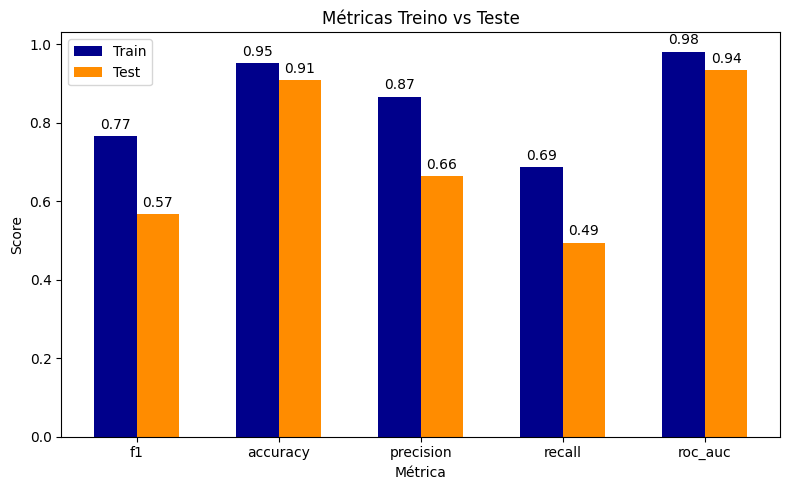

In [34]:
plot_train_test_metrics(train_metrics, test_metrics)

## Explicação da performance com LLM 

In [35]:
template = '''
You are an expert in evaluating machine learning performance.

Given the input in JSON format containing the calculated performance 
metrics, explain in clear, simple, and technical language the performance of our model.

Provide the response in bullet points.

Ipunt (JSON):
{all_model_metrics}
'''

prompt_template = PromptTemplate.from_template(
    template=template
)

In [ ]:
llm_model = ChatGroq(
    model='llama-3.3-70b-versatile',
    temperature=0,
    max_tokens=300,
    timeout=None,
    max_retries=2,
    verbose=False
)

In [37]:
system_prompt = 'How did the model perform on the training and test datasets?'
user_prompt = prompt_template.format(all_model_metrics=all_metrics.to_json())
messages = [
    SystemMessage(content=system_prompt),
    HumanMessage(content=user_prompt)
]

response = llm_model.invoke(messages)
print(f'🤖: {response.content}')

🤖: Here's a clear and simple explanation of the model's performance in bullet points:

* **Training Performance:**
  * The model achieved a high accuracy of 95.31% on the training dataset, indicating that it was able to correctly 
classify most of the training samples.
  * The F1 score of 0.77 suggests a good balance between precision (0.87) and recall (0.69) on the training 
dataset.
  * The ROC-AUC score of 0.98 indicates excellent discrimination between positive and negative classes on the 
training dataset.

* **Testing Performance:**
  * The model's accuracy on the test dataset was 90.87%, which is lower than the training accuracy, indicating some
degree of overfitting.
  * The F1 score of 0.57 on the test dataset is lower than the training F1 score, suggesting a decrease in 
performance on unseen data.
  * The precision (0.66) and recall (0.49) on the test dataset are lower than the training precision and recall, 
indicating a potential bias towards false negatives.
  * The ROC-AUC score of 0.94 on the test dataset is still relatively high, indicating good discrimination between 
positive and negative classes, but lower than the training ROC-AUC score.

* **Overall Performance:**
  * The model performs well on the training dataset but experiences a drop in performance on the test dataset, 
indicating potential overfitting.
  * The model's

## Próximos passos

- Explorar algumas questões sobre este dataset seguindo o seguinte trabalho **"Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. Decis. Support Syst., 62, 22-31"**.

<img src='imgs/table1.png' size='40%'>

<br/>

## Informações sobre o dataset Bank Marketing (UCI)

In [38]:
with open(PATH_INFOS_BANK_FULL, 'r', encoding='utf-8') as f:
    content = f.read()
print(content)

Citation Request:
  This dataset is public available for research. The details are described in [Moro et al., 2011]. 
  Please include this citation if you plan to use this database:

  [Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An 
Application of the CRISP-DM Methodology. 
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 
117-121, Guimarães, Portugal, October, 2011. EUROSIS.

  Available at:  http://hdl.handle.net/1822/14838
                 http://www3.dsi.uminho.pt/pcortez/bib/2011-esm-1.txt

1. Title: Bank Marketing

2. Sources
   Created by: Paulo Cortez (Univ. Minho) and Sérgio Moro (ISCTE-IUL) @ 2012
   
3. Past Usage:

  The full dataset was described and analyzed in:

  S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM 
Methodology. 
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 
117-121, Guimarães, 
  Portugal, October, 2011. EUROSIS.

4. Relevant Information:

   The data is related with direct marketing campaigns of a Portuguese banking institution. 
   The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required,
   in order to access if the product (bank term deposit) would be (or not) subscribed. 

   There are two datasets: 
      1) bank-full.csv with all examples, ordered by date (from May 2008 to November 2010).
      2) bank.csv with 10% of the examples (4521), randomly selected from bank-full.csv.
   The smallest dataset is provided to test more computationally demanding machine learning algorithms (e.g. SVM).

   The classification goal is to predict if the client will subscribe a term deposit (variable y).

5. Number of Instances: 45211 for bank-full.csv (4521 for bank.csv)

6. Number of Attributes: 16 + output attribute.

7. Attribute information:

   For more information, read [Moro et al., 2011].

   Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: 
"admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or 
widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric) 
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last 
contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, 
-1 means client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")

8. Missing Attribute Values: None